## Supplement Figure 3: Speed At Home

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pickle
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ranksums

In [3]:
from spyglass.shijiegu.Analysis_SGU import get_linearization_map

from spyglass.shijiegu.Analysis_SGU import TrialChoice, DecodeIngredients, DecodeResults2D, ChangeofMindTheta, DecodeResultsLinear
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.decoding.v0.visualization import make_single_environment_movie
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_triggered import linear_map, select_subset_helper_position
from spyglass.shijiegu.changeOfMind_remote import find_posterior_sum_segment, find_remote_theta_animal_new

[2025-10-11 18:15:05,590][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[18:15:12][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[18:15:12][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[18:15:12][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[18:15:12][WARNING] Spyglass: Deprecation: this class has b

In [8]:
encoding_sets = {}
classifier_param_names = {}
days = {}

data_folder = '/stelmo/shijie/change_of_mind_analysis/figure2'

# load triggered_position_decode
animal = "Molly"
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20220418'

animal = "Eliot"
encoding_sets[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20221021'

animal = "Klein"
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20231107'

animal = "Julio"
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20230731'

animal = "Lewis"
encoding_sets[animal] = '2Dheadspeed_above_4'
classifier_param_names[animal] = 'default_decoding_gpu_4armMaze'
# a single day
days[animal] = '20240105'

In [12]:
def figure_supp3_speed(animal, day, data):
    fig,axes = plt.subplots(1,1,figsize = (5,3))
    
    home_bins = np.linspace(15, 57, 50)
    
    speed2d_all = []
    speed2d_control_all = []
    for trial in range(len(data['positions_2D'])):
        pos1d = np.array(data['positions'][trial])
        home_ind = np.logical_and(pos1d >= 15, pos1d <= 57)
        pos1d = pos1d[home_ind]
        speed2d = np.array(data['positions_2D'][trial].head_speed)[home_ind]
    
        bin_index = np.digitize(pos1d, home_bins)
        speed2d = [np.mean(speed2d[bin_index == i]) for i in range(len(home_bins))]
        speed2d_all.append(speed2d)
        plt.plot(home_bins, speed2d, linewidth = 1, color = 'C1', alpha = 0.1)
    
        # control
        pos1d = np.array(data['positions_control'][trial])
        home_ind = np.logical_and(pos1d >= 15, pos1d <= 57)
        pos1d = pos1d[home_ind]
        speed2d = np.array(data['positions_2D_control'][trial].head_speed)[home_ind]
    
        bin_index = np.digitize(pos1d, home_bins)
        speed2d = [np.mean(speed2d[bin_index == i]) for i in range(len(home_bins))]
        speed2d_control_all.append(speed2d)
        axes.plot(home_bins, speed2d, linewidth = 1, color = 'k', alpha = 0.1)
    
    speed2d_mean = np.nanmean(np.array(speed2d_all), axis = 0)
    speed2d_std = np.nanstd(np.array(speed2d_all), axis = 0)
    axes.fill_between(home_bins,
                      speed2d_mean - speed2d_std,
                      speed2d_mean + speed2d_std, alpha = 0.3, color = 'C1',label = "change of mind", zorder = -np.inf)
    
    speed2d_mean = np.nanmean(np.array(speed2d_control_all), axis = 0)
    speed2d_std = np.nanstd(np.array(speed2d_control_all), axis = 0)
    axes.fill_between(home_bins,
                      speed2d_mean - speed2d_std,
                      speed2d_mean + speed2d_std, alpha = 0.3, color = 'k',label = "control", zorder = -np.inf)
    axes.legend()
    #axes.set_xticklabels([str(int(np.round(p))) for p in np.mean(home_positions,axis = 1)])
    axes.set_title(f"{animal}\n{day}\nspeed in home arm")
    axes.set_ylabel("speed, cm/s")
    axes.set_xlabel("home arm location (cm)")
    axes.set_ylim([np.nanmin([speed2d_mean - 2*speed2d_std]), np.nanmax([speed2d_mean + 2*speed2d_std])])
    
    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/suppfigure3"
    plt.savefig(f"{animal}_{day}_home_speed.pdf")
    plt.savefig(f"{animal}_{day}_home_speed.png")

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Molly_speed.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Eliot_speed.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Klein_speed.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Lewis_speed.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure2/Julio_speed.pickle


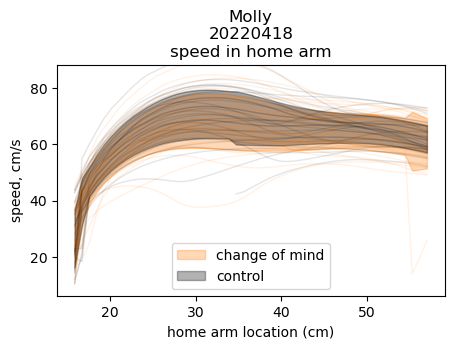

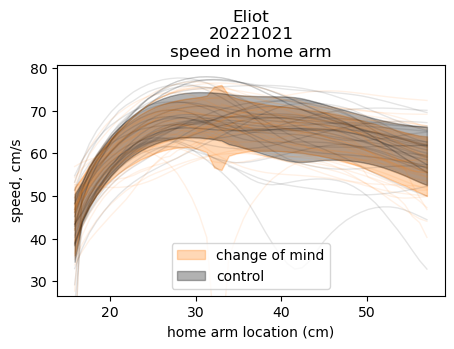

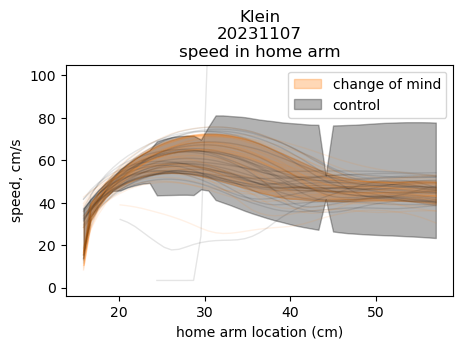

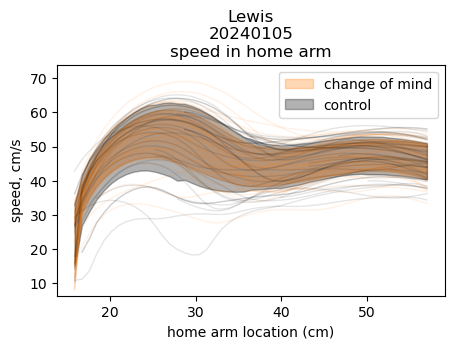

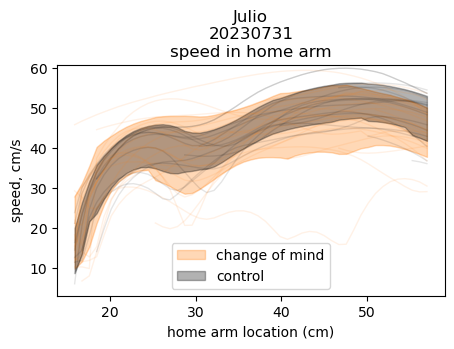

In [13]:
for animal in ["Molly","Eliot","Klein","Lewis","Julio"]:
    day = days[animal]
    encoding_set = encoding_sets[animal]
    classifier_param_name = classifier_param_names[animal]

    # load data parsed for figure 2
    file_path = f"{data_folder}/{animal}_speed.pickle"
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")

    figure_supp3_speed(animal, day, data)
        
    #figure_speed_plot(data["positions"], data["positions_2D"], data["positions_control"], data["positions_2D_control"])